## Installing all useful libraries 

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
df = pd.read_csv('stock dataset.csv') # Load dataset

In [3]:
df.head() # Show first 5 rows

,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
0,1/4/2010,AAPL,6.395005,6.427065,6.363544,6.412384,6.412384,493729600
1,1/4/2010,AMZN,6.812500,6.830500,6.657000,6.695000,6.695000,151998000
2,1/4/2010,AVGO,1.289115,1.331381,1.268686,1.328563,1.328563,5387000
3,1/4/2010,GOOG,15.498976,15.562262,15.431981,15.494032,15.494032,78541293
4,1/4/2010,GOOGL,15.571782,15.635366,15.504474,15.566814,15.566814,78169752


In [4]:
df.info() # Get info about dataset (data types, non-null counts)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35765 entries, 0 to 35764
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       35765 non-null  object 
 1   Ticker     35765 non-null  object 
 2   Open       35765 non-null  float64
 3   High       35765 non-null  float64
 4   Low        35765 non-null  float64
 5   Close      35765 non-null  float64
 6   Adj_Close  35765 non-null  float64
 7   Volume     35765 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 2.2+ MB


In [5]:
df.describe() # Get summary statistics (mean, std, min, max, etc.) for numeric columns

,Open,High,Low,Close,Adj_Close,Volume
count,35765.000000,35765.000000,35765.000000,35765.000000,35765.000000,3.576500e+04
mean,92.590518,93.765511,91.365589,92.595168,92.595168,1.202461e+08
std,115.952363,117.408637,114.358373,115.898831,115.898831,1.919208e+08
min,0.199870,0.207434,0.198265,0.203537,0.203537,1.584340e+05
25%,15.297000,15.460000,15.125859,15.300667,15.300667,2.544150e+07
50%,41.214919,41.580309,40.863378,41.232372,41.232372,4.974370e+07
75%,140.091398,141.880992,138.391384,140.202179,140.202179,1.129584e+08
max,789.972166,795.064526,779.657506,788.823791,788.823791,3.692928e+09


In [6]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
# Sort by date
df = df.sort_values('Date')

In [8]:
# Set Date as index
df.set_index('Date', inplace=True)

In [9]:
# Check missing values
df.isnull().sum()

Ticker       0
Open         0
High         0
Low          0
Close        0
Adj_Close    0
Volume       0
dtype: int64

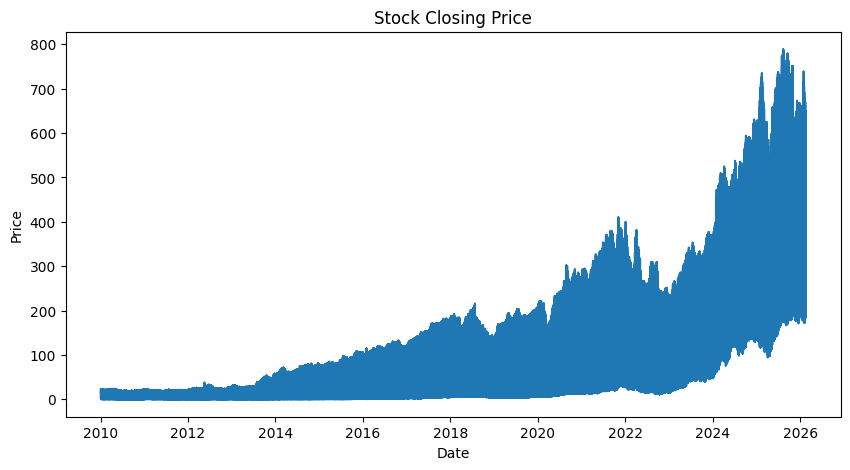

In [10]:
import matplotlib.pyplot as plt # Visualize closing price over time

plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

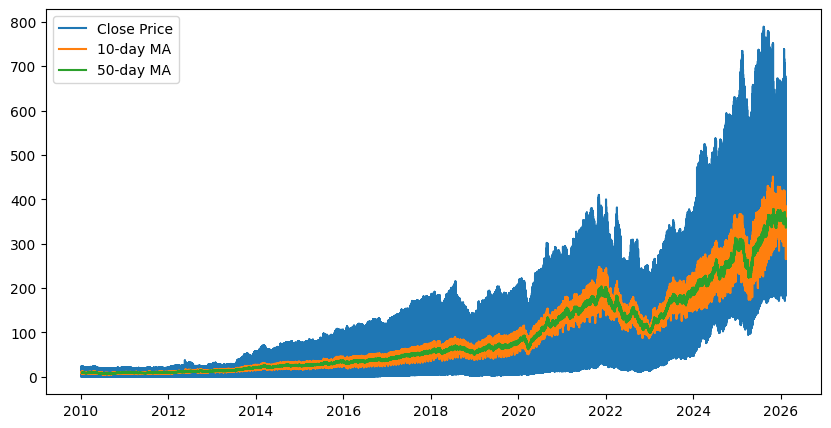

In [11]:
df['MA_10'] = df['Close'].rolling(window=10).mean() # Calculate 10-day moving average
df['MA_50'] = df['Close'].rolling(window=50).mean() # Calculate 50-day moving average

plt.figure(figsize=(10,5)) 
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA_10'], label='10-day MA')
plt.plot(df['MA_50'], label='50-day MA')
plt.legend()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split # Prepare data for modeling

# Create feature & target
df['Target'] = df['Close'].shift(-1)

# Drop last row (NaN target)
df = df.dropna()

X = df[['Close']]
y = df['Target']

In [13]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [14]:
from sklearn.linear_model import LinearRegression # Train using linear regression model

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


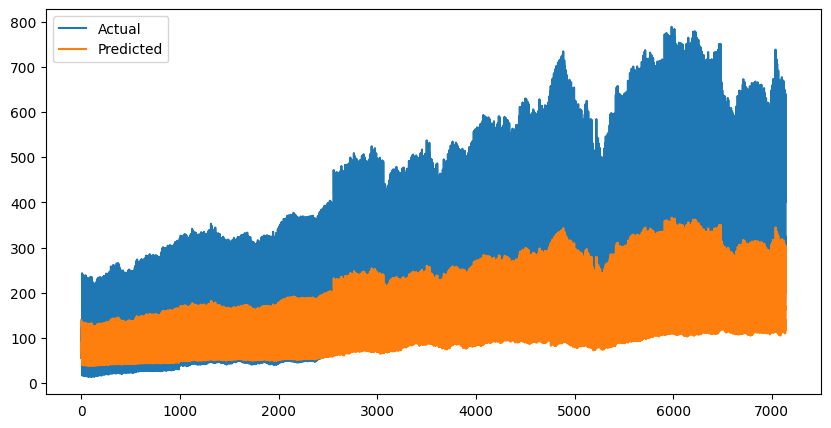

In [15]:
predictions = model.predict(X_test) # Predict on test set

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

MSE: 32433.80131355078


In [17]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


2026-04-25 15:11:15.364 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:15.727 
  command:

    streamlit run c:\Users\ASUS\anaconda3\envs\ml_env\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-25 15:11:15.727 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:15.728 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:15.733 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:15.734 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:15.735 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:15.745 Thread 'Main

DeltaGenerator()

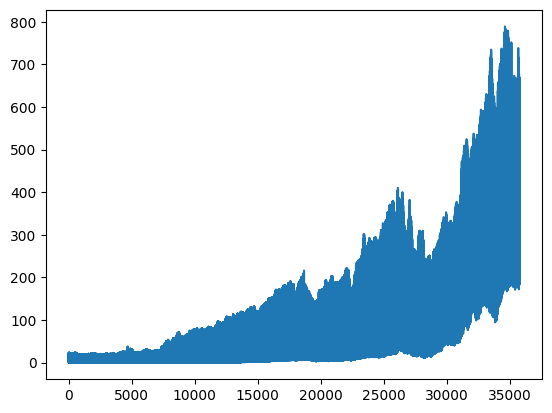

In [18]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('stock dataset.csv')

st.title("Stock Price Analyzer")

st.write(df.head())

plt.plot(df['Close'])
st.pyplot(plt)

## RSI tells overbought / oversold conditions
## RSI=100 - 100/(1+RS)
## RSI tells if stock is:(1) Overbought (>70), (2) Oversold (<30)

In [19]:
import numpy as np ## Calculate RSI (Relative Strength Index

def compute_rsi(data, window=14):
    delta = data['Close'].diff()

    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()

    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

df['RSI'] = compute_rsi(df)

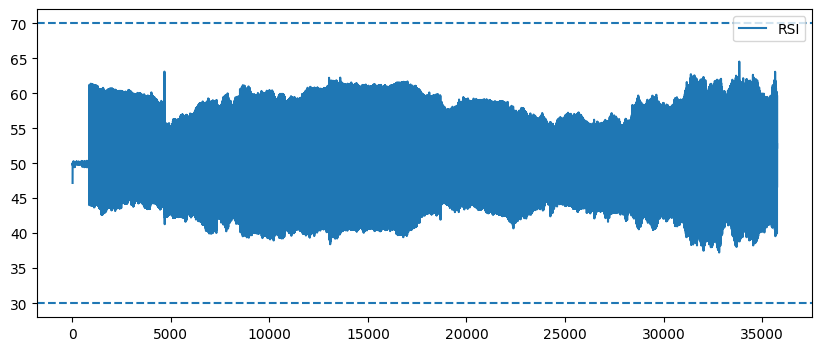

In [20]:
plt.figure(figsize=(10,4)) ## Visualize RSI
plt.plot(df['RSI'], label='RSI')
plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')
plt.legend()
plt.show()

## Shows trend + momentum, Used by professional traders

In [21]:
exp1 = df['Close'].ewm(span=12, adjust=False).mean() # Calculate 12-day EMA for MACD
exp2 = df['Close'].ewm(span=26, adjust=False).mean()

df['MACD'] = exp1 - exp2
df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

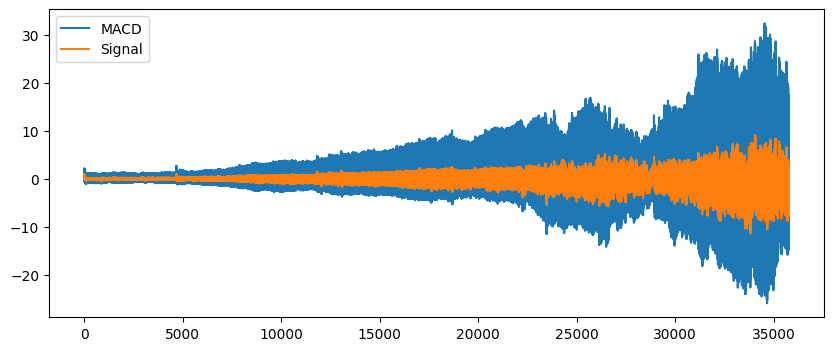

In [22]:
plt.figure(figsize=(10,4))
plt.plot(df['MACD'], label='MACD')
plt.plot(df['Signal'], label='Signal')
plt.legend()
plt.show()

## Bollinger Bands,Shows volatility,Helps identify breakout zones

In [23]:
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['STD'] = df['Close'].rolling(window=20).std()

df['Upper'] = df['MA_20'] + (df['STD'] * 2)
df['Lower'] = df['MA_20'] - (df['STD'] * 2)

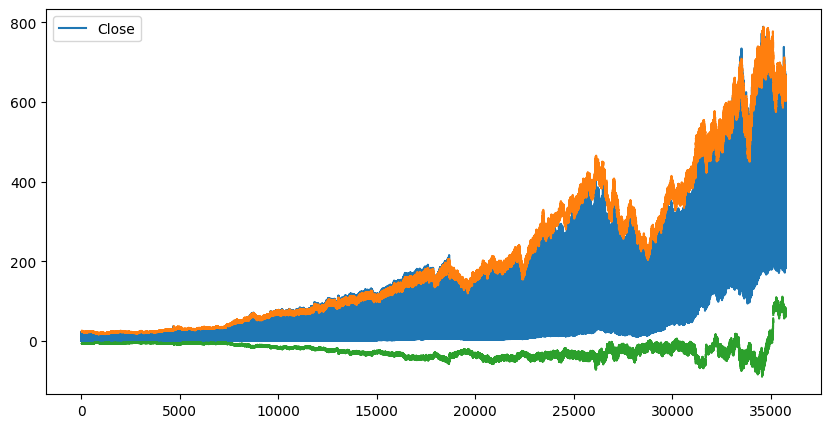

In [24]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Close')
plt.plot(df['Upper'], linestyle='--')
plt.plot(df['Lower'], linestyle='--')
plt.legend()
plt.show()

In [25]:
from sklearn.ensemble import RandomForestRegressor # Train using random forest regression model , Handles non-linear data

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
from sklearn.metrics import mean_absolute_error, r2_score # Evaluate model performance using MAE and R2 score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 131.17423076542678
R2 Score: -0.5125628183909738


In [27]:
import streamlit as st # Add interactive elements to Streamlit appt.sidebar.title("Settings")

show_rsi = st.sidebar.checkbox("Show RSI")
show_macd = st.sidebar.checkbox("Show MACD")

2026-04-25 15:11:22.137 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.138 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.139 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.140 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.141 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.141 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.142 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.142 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [28]:
if show_rsi: # Show RSI chart if checkbox is selected
    st.subheader("RSI")
    st.line_chart(df['RSI'])

if show_macd:
    st.subheader("MACD")
    st.line_chart(df[['MACD', 'Signal']])

In [29]:
uploaded_file = st.file_uploader("Upload CSV", type=['csv']) # Allow users to upload their own CSV file

if uploaded_file:
    df = pd.read_csv(uploaded_file)

2026-04-25 15:11:22.170 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.170 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.171 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.172 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.172 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.173 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [30]:
csv = df.to_csv().encode('utf-8') # Provide download button for processed data

st.download_button(
    label="Download Processed Data",
    data=csv,
    file_name='processed_stock.csv',
    mime='text/csv',
)

2026-04-25 15:11:22.596 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.596 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.598 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.598 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.599 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.599 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 15:11:22.599 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


False